In [1]:
%matplotlib notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle, Rectangle
from IPython.display import HTML

class Obstacle:
    """Simple obstacle class"""
    def __init__(self, x, y, radius):
        self.x = x
        self.y = y
        self.radius = radius
    
    def distance_to_point(self, x, y):
        """Calculate distance from point to obstacle surface"""
        dist = np.sqrt((x - self.x)**2 + (y - self.y)**2)
        return max(0, dist - self.radius)


class BeamSensor:
    """Simulates a beam sensor without PyBullet"""
    
    def __init__(self, max_range=5.0, num_rays=21, fov=np.pi, noise_std=0.02):
        self.max_range = max_range
        self.num_rays = num_rays
        self.fov = fov
        self.noise_std = noise_std
    
    def cast_ray(self, x, y, angle, obstacles):
        """Cast a single ray and find nearest obstacle"""
        # Ray direction
        dx = np.cos(angle)
        dy = np.sin(angle)
        
        min_distance = self.max_range
        hit_point = (x + dx * self.max_range, y + dy * self.max_range)
        
        # Check intersection with each obstacle
        for obs in obstacles:
            # Vector from ray origin to obstacle center
            to_obs_x = obs.x - x
            to_obs_y = obs.y - y
            
            # Project onto ray direction
            t = to_obs_x * dx + to_obs_y * dy
            
            if t < 0:  # Obstacle behind ray
                continue
            
            # Closest point on ray to obstacle center
            closest_x = x + t * dx
            closest_y = y + t * dy
            
            # Distance from closest point to obstacle center
            dist_to_center = np.sqrt((closest_x - obs.x)**2 + (closest_y - obs.y)**2)
            
            # Check if ray intersects obstacle
            if dist_to_center <= obs.radius:
                # Calculate intersection point
                # Distance along ray to intersection
                d = t - np.sqrt(obs.radius**2 - dist_to_center**2)
                
                if d > 0 and d < min_distance:
                    min_distance = d
                    hit_point = (x + d * dx, y + d * dy)
        
        # Add noise
        distance = min_distance + np.random.normal(0, self.noise_std)
        distance = np.clip(distance, 0, self.max_range)
        
        return distance, hit_point
    
    def get_measurements(self, x, y, theta, obstacles):
        """Get all sensor measurements"""
        measurements = []
        
        if self.num_rays == 1:
            angles = [theta]
        else:
            angles = np.linspace(theta - self.fov/2, theta + self.fov/2, self.num_rays)
        
        for angle in angles:
            distance, hit_point = self.cast_ray(x, y, angle, obstacles)
            measurements.append({
                'angle': angle - theta,  # Relative to robot
                'absolute_angle': angle,
                'distance': distance,
                'hit_point': hit_point,
                'ray_start': (x, y)
            })
        
        return measurements


class Robot:
    """Simple robot class"""
    def __init__(self, x=0, y=0, theta=0):
        self.x = x
        self.y = y
        self.theta = theta
        self.radius = 0.3
        self.prev_x = x
        self.prev_y = y
    
    def move_circular(self, t, radius=2.0, speed=0.5):
        """Move in circular path (DEFAULT)"""
        angle = speed * t
        self.x = radius * np.cos(angle)
        self.y = radius * np.sin(angle)
        self.theta = angle + np.pi
    
    def move_straight(self, t, speed=0.3):
        """Move in straight line from left to right"""
        self.x = -3 + speed * t
        self.y = 0
        self.theta = 0  # Face right
        
        # Reverse when hitting boundary
        if self.x > 3:
            self.x = 3
            self.theta = np.pi  # Face left
        elif self.x < -3:
            self.x = -3
            self.theta = 0  # Face right
    
    def move_figure8(self, t, scale=2.0, speed=0.3):
        """Move in figure-8 pattern (lemniscate)"""
        angle = speed * t
        self.x = scale * np.sin(angle)
        self.y = scale * np.sin(angle) * np.cos(angle)
        
        # Calculate heading from velocity
        dx = scale * speed * np.cos(angle)
        dy = scale * speed * (np.cos(2*angle))
        self.theta = np.arctan2(dy, dx)
    
    def move_square(self, t, size=3.0, speed=0.5):
        """Move in square pattern"""
        perimeter = 4 * size
        pos = (speed * t) % perimeter
        
        if pos < size:  # Right side
            self.x = -size/2 + pos
            self.y = -size/2
            self.theta = 0
        elif pos < 2*size:  # Top side
            self.x = size/2
            self.y = -size/2 + (pos - size)
            self.theta = np.pi/2
        elif pos < 3*size:  # Left side
            self.x = size/2 - (pos - 2*size)
            self.y = size/2
            self.theta = np.pi
        else:  # Bottom side
            self.x = -size/2
            self.y = size/2 - (pos - 3*size)
            self.theta = 3*np.pi/2
    
    def move_zigzag(self, t, amplitude=2.0, wavelength=4.0, speed=0.3):
        """Move in zigzag pattern"""
        self.x = -3 + speed * t
        self.y = amplitude * np.sin(2 * np.pi * self.x / wavelength)
        
        # Calculate heading from derivative
        dy_dx = amplitude * (2 * np.pi / wavelength) * np.cos(2 * np.pi * self.x / wavelength)
        self.theta = np.arctan(dy_dx)
        
        # Reset when reaching boundary
        if self.x > 3:
            self.x = -3
    
    def move_spiral(self, t, speed=0.3, growth=0.05):
        """Move in expanding spiral"""
        angle = speed * t
        radius = growth * angle
        self.x = radius * np.cos(angle)
        self.y = radius * np.sin(angle)
        self.theta = angle + np.pi/2
    
    def move_random_walk(self, t, step_size=0.1):
        """Random walk motion (Brownian motion)"""
        # Store previous position
        self.prev_x = self.x
        self.prev_y = self.y
        
        # Random step
        self.x += np.random.normal(0, step_size)
        self.y += np.random.normal(0, step_size)
        
        # Keep within bounds
        self.x = np.clip(self.x, -4, 4)
        self.y = np.clip(self.y, -4, 4)
        
        # Calculate heading from movement
        dx = self.x - self.prev_x
        dy = self.y - self.prev_y
        if dx != 0 or dy != 0:
            self.theta = np.arctan2(dy, dx)
    
    def move_lissajous(self, t, a=2.0, b=2.0, delta=np.pi/2):
        """Move in Lissajous curve pattern"""
        self.x = a * np.sin(t + delta)
        self.y = b * np.sin(2 * t)
        
        # Calculate heading from velocity
        dx = a * np.cos(t + delta)
        dy = 2 * b * np.cos(2 * t)
        self.theta = np.arctan2(dy, dx)


def create_animation(num_frames=200):
    """Create animated beam sensor simulation"""
    
    # Create obstacles
    obstacles = [
        Obstacle(2, 0, 0.5),
        Obstacle(1, 1.5, 0.4),
        Obstacle(-1, -1, 0.5),
        Obstacle(0, -2, 0.4),
        Obstacle(-2, 1, 0.5),
    ]
    
    # Create robot and sensor
    robot = Robot()
    sensor = BeamSensor(max_range=4.0, num_rays=21, fov=np.pi, noise_std=0.02)
    
    # Setup figure
    fig = plt.figure(figsize=(15, 6))
    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122, projection='polar')
    
    # Configure top-down view
    ax1.set_xlim(-5, 5)
    ax1.set_ylim(-5, 5)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X (meters)', fontsize=12)
    ax1.set_ylabel('Y (meters)', fontsize=12)
    ax1.set_title('Top-Down View - Beam Sensor Simulation', fontsize=14, fontweight='bold')
    
    # Draw obstacles
    for obs in obstacles:
        circle = Circle((obs.x, obs.y), obs.radius, color='gray', alpha=0.7, zorder=1)
        ax1.add_patch(circle)
        ax1.plot(obs.x, obs.y, 'kx', markersize=8)
    
    # Initialize robot visualization
    robot_circle = Circle((0, 0), robot.radius, color='blue', alpha=0.8, zorder=2)
    ax1.add_patch(robot_circle)
    robot_arrow = ax1.arrow(0, 0, 0, 0, head_width=0.2, head_length=0.2, 
                           fc='blue', ec='blue', zorder=3)
    
    # Initialize ray lines
    ray_lines = []
    for i in range(sensor.num_rays):
        line, = ax1.plot([], [], 'r-', linewidth=1.5, alpha=0.7, zorder=2)
        ray_lines.append(line)
    
    # Configure polar plot
    ax2.set_ylim(0, sensor.max_range)
    ax2.set_title('Sensor Scan (Polar View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.5)
    polar_line, = ax2.plot([], [], 'o-', linewidth=2, markersize=6, color='red')
    polar_fill = None
    
    # Add text for info
    info_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, 
                        verticalalignment='top', fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    def init():
        """Initialize animation"""
        for line in ray_lines:
            line.set_data([], [])
        polar_line.set_data([], [])
        return ray_lines + [polar_line, robot_circle, info_text]
    
    def update(frame):
        """Update animation frame"""
        nonlocal polar_fill, robot_arrow
        
        # Update robot position
        t = frame * 0.1
        
        # ============================================================
        # MOTION PATTERNS - Uncomment ONE to use
        # ============================================================
        
        # DEFAULT: Circular motion
        robot.move_circular(t)
        
        # OPTION 1: Straight line (left to right)
        # robot.move_straight(t)
        
        # OPTION 2: Figure-8 pattern
        # robot.move_figure8(t)
        
        # OPTION 3: Square pattern
        # robot.move_square(t)
        
        # OPTION 4: Zigzag pattern
        # robot.move_zigzag(t)
        
        # OPTION 5: Spiral (expanding outward)
        # robot.move_spiral(t)
        
        # OPTION 6: Random walk
        # robot.move_random_walk(t)
        
        # OPTION 7: Lissajous curve (complex pattern)
        # robot.move_lissajous(t)
        
        # ============================================================
        
        # Update robot visualization
        robot_circle.center = (robot.x, robot.y)
        
        # Remove old arrow and create new one
        robot_arrow.remove()
        arrow_length = 0.5
        robot_arrow = ax1.arrow(robot.x, robot.y, 
                               arrow_length * np.cos(robot.theta),
                               arrow_length * np.sin(robot.theta),
                               head_width=0.2, head_length=0.2,
                               fc='blue', ec='blue', zorder=3)
        
        # Get sensor measurements
        measurements = sensor.get_measurements(robot.x, robot.y, robot.theta, obstacles)
        
        # Update ray lines
        for line, m in zip(ray_lines, measurements):
            line.set_data([m['ray_start'][0], m['hit_point'][0]], 
                         [m['ray_start'][1], m['hit_point'][1]])
        
        # Update polar plot
        angles = [m['angle'] for m in measurements]
        distances = [m['distance'] for m in measurements]
        polar_line.set_data(angles, distances)
        
        # Update polar fill
        if polar_fill:
            for coll in polar_fill.collections:
                coll.remove()
        polar_fill = ax2.fill(angles, distances, alpha=0.25, color='red')
        
        # Update info text
        min_dist = min(distances)
        avg_dist = np.mean(distances)
        info_text.set_text(f'Frame: {frame}\n'
                          f'Robot: ({robot.x:.2f}, {robot.y:.2f})\n'
                          f'Angle: {np.degrees(robot.theta):.1f}°\n'
                          f'Min distance: {min_dist:.2f}m\n'
                          f'Avg distance: {avg_dist:.2f}m')
        
        return ray_lines + [polar_line, robot_circle, robot_arrow, info_text]
    
    # Create animation
    anim = FuncAnimation(fig, update, init_func=init, frames=num_frames, 
                        interval=50, blit=False, repeat=True)
    
    plt.tight_layout()
    return anim, fig


def run_simulation(frames=200):
    """Run the simulation (call this function directly)"""
    print("Beam Sensor Simulation (No PyBullet Required)")
    print("=" * 60)
    print("Starting animation...")
    print("Controls:")
    print("  - Click ■ (stop button) in toolbar to pause")
    print("  - Click ▶ (play button) to resume")
    print("  - Close window or run: plt.close('all') to stop")
    print("=" * 60)
    
    anim, fig = create_animation(frames)
    plt.show()
    
    # Keep reference to prevent garbage collection
    return anim, fig


def create_animation_with_controls(num_frames=200):
    """Create animation with built-in controls"""
    from matplotlib.widgets import Button
    
    # Create obstacles
    obstacles = [
        Obstacle(2, 0, 0.5),
        Obstacle(1, 1.5, 0.4),
        Obstacle(-1, -1, 0.5),
        Obstacle(0, -2, 0.4),
        Obstacle(-2, 1, 0.5),
    ]
    
    # Create robot and sensor
    robot = Robot()
    sensor = BeamSensor(max_range=4.0, num_rays=21, fov=np.pi, noise_std=0.02)
    
    # Setup figure with more space for buttons
    fig = plt.figure(figsize=(15, 7))
    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122, projection='polar')
    
    # Animation control state
    anim_running = {'running': True}
    
    # Configure top-down view
    ax1.set_xlim(-5, 5)
    ax1.set_ylim(-5, 5)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X (meters)', fontsize=12)
    ax1.set_ylabel('Y (meters)', fontsize=12)
    ax1.set_title('Top-Down View - Beam Sensor Simulation', fontsize=14, fontweight='bold')
    
    # Draw obstacles
    for obs in obstacles:
        circle = Circle((obs.x, obs.y), obs.radius, color='gray', alpha=0.7, zorder=1)
        ax1.add_patch(circle)
        ax1.plot(obs.x, obs.y, 'kx', markersize=8)
    
    # Initialize robot visualization
    robot_circle = Circle((0, 0), robot.radius, color='blue', alpha=0.8, zorder=2)
    ax1.add_patch(robot_circle)
    robot_arrow = ax1.arrow(0, 0, 0, 0, head_width=0.2, head_length=0.2, 
                           fc='blue', ec='blue', zorder=3)
    
    # Initialize ray lines
    ray_lines = []
    for i in range(sensor.num_rays):
        line, = ax1.plot([], [], 'r-', linewidth=1.5, alpha=0.7, zorder=2)
        ray_lines.append(line)
    
    # Configure polar plot
    ax2.set_ylim(0, sensor.max_range)
    ax2.set_title('Sensor Scan (Polar View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.5)
    polar_line, = ax2.plot([], [], 'o-', linewidth=2, markersize=6, color='red')
    polar_fill = None
    
    # Add text for info
    info_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, 
                        verticalalignment='top', fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    def init():
        """Initialize animation"""
        for line in ray_lines:
            line.set_data([], [])
        polar_line.set_data([], [])
        return ray_lines + [polar_line, robot_circle, info_text]
    
    def update(frame):
        """Update animation frame"""
        nonlocal polar_fill, robot_arrow
        
        if not anim_running['running']:
            return ray_lines + [polar_line, robot_circle, robot_arrow, info_text]
        
        # Update robot position
        t = frame * 0.1
        robot.move_zigzag(t)
        
        # Update robot visualization
        robot_circle.center = (robot.x, robot.y)
        
        # Remove old arrow and create new one
        robot_arrow.remove()
        arrow_length = 0.5
        robot_arrow = ax1.arrow(robot.x, robot.y, 
                               arrow_length * np.cos(robot.theta),
                               arrow_length * np.sin(robot.theta),
                               head_width=0.2, head_length=0.2,
                               fc='blue', ec='blue', zorder=3)
        
        # Get sensor measurements
        measurements = sensor.get_measurements(robot.x, robot.y, robot.theta, obstacles)
        
        # Update ray lines
        for line, m in zip(ray_lines, measurements):
            line.set_data([m['ray_start'][0], m['hit_point'][0]], 
                         [m['ray_start'][1], m['hit_point'][1]])
        
        # Update polar plot
        angles = [m['angle'] for m in measurements]
        distances = [m['distance'] for m in measurements]
        polar_line.set_data(angles, distances)
        
        # Update polar fill
        if polar_fill:
            for coll in polar_fill.collections:
                coll.remove()
        polar_fill = ax2.fill(angles, distances, alpha=0.25, color='red')
        
        # Update info text
        min_dist = min(distances)
        avg_dist = np.mean(distances)
        status = "RUNNING" if anim_running['running'] else "PAUSED"
        info_text.set_text(f'Status: {status}\n'
                          f'Frame: {frame}\n'
                          f'Robot: ({robot.x:.2f}, {robot.y:.2f})\n'
                          f'Angle: {np.degrees(robot.theta):.1f}°\n'
                          f'Min distance: {min_dist:.2f}m\n'
                          f'Avg distance: {avg_dist:.2f}m')
        
        return ray_lines + [polar_line, robot_circle, robot_arrow, info_text]
    
    # Create animation
    anim = FuncAnimation(fig, update, init_func=init, frames=num_frames, 
                        interval=50, blit=False, repeat=True)
    
    plt.tight_layout()
    return anim, fig


# Main execution
if __name__ == "__main__":
    print("Beam Sensor Simulation (No PyBullet Required)")
    print("=" * 60)
    print("This is a pure Python/NumPy implementation")
    print("\nTo run, use:")
    print("  anim, fig = run_simulation()")
    print("\nOr step by step:")
    print("  anim, fig = create_animation()")
    print("  plt.show()")
    print("\n" + "=" * 60)
    print("MOTION PATTERNS AVAILABLE:")
    print("=" * 60)
    print("DEFAULT: Circular motion - Robot moves in a circle")
    print("OPTION 1: Straight line - Left to right motion")
    print("OPTION 2: Figure-8 - Smooth infinity symbol path")
    print("OPTION 3: Square - Follow square perimeter")
    print("OPTION 4: Zigzag - Sine wave pattern")
    print("OPTION 5: Spiral - Expanding outward spiral")
    print("OPTION 6: Random walk - Unpredictable motion")
    print("OPTION 7: Lissajous - Complex harmonic pattern")
    print("\nTo change pattern:")
    print("1. Find the update() function in create_animation()")
    print("2. Comment the current motion (add # at start)")
    print("3. Uncomment your desired option (remove #)")
    print("4. Re-run: anim, fig = run_simulation()")
    print("=" * 60)
    print("\nTo save animation:")
    print("  anim.save('beam_sensor.gif', writer='pillow', fps=20)")
    print("=" * 60)

Beam Sensor Simulation (No PyBullet Required)
This is a pure Python/NumPy implementation

To run, use:
  anim, fig = run_simulation()

Or step by step:
  anim, fig = create_animation()
  plt.show()

MOTION PATTERNS AVAILABLE:
DEFAULT: Circular motion - Robot moves in a circle
OPTION 1: Straight line - Left to right motion
OPTION 2: Figure-8 - Smooth infinity symbol path
OPTION 3: Square - Follow square perimeter
OPTION 4: Zigzag - Sine wave pattern
OPTION 5: Spiral - Expanding outward spiral
OPTION 6: Random walk - Unpredictable motion
OPTION 7: Lissajous - Complex harmonic pattern

To change pattern:
1. Find the update() function in create_animation()
2. Comment the current motion (add # at start)
3. Uncomment your desired option (remove #)
4. Re-run: anim, fig = run_simulation()

To save animation:
  anim.save('beam_sensor.gif', writer='pillow', fps=20)


Beam Sensor Simulation (No PyBullet Required)
Starting animation...
Controls:
  - Click ■ (stop button) in toolbar to pause
  - Click ▶ (play button) to resume
  - Close window or run: plt.close('all') to stop


<IPython.core.display.Javascript object>


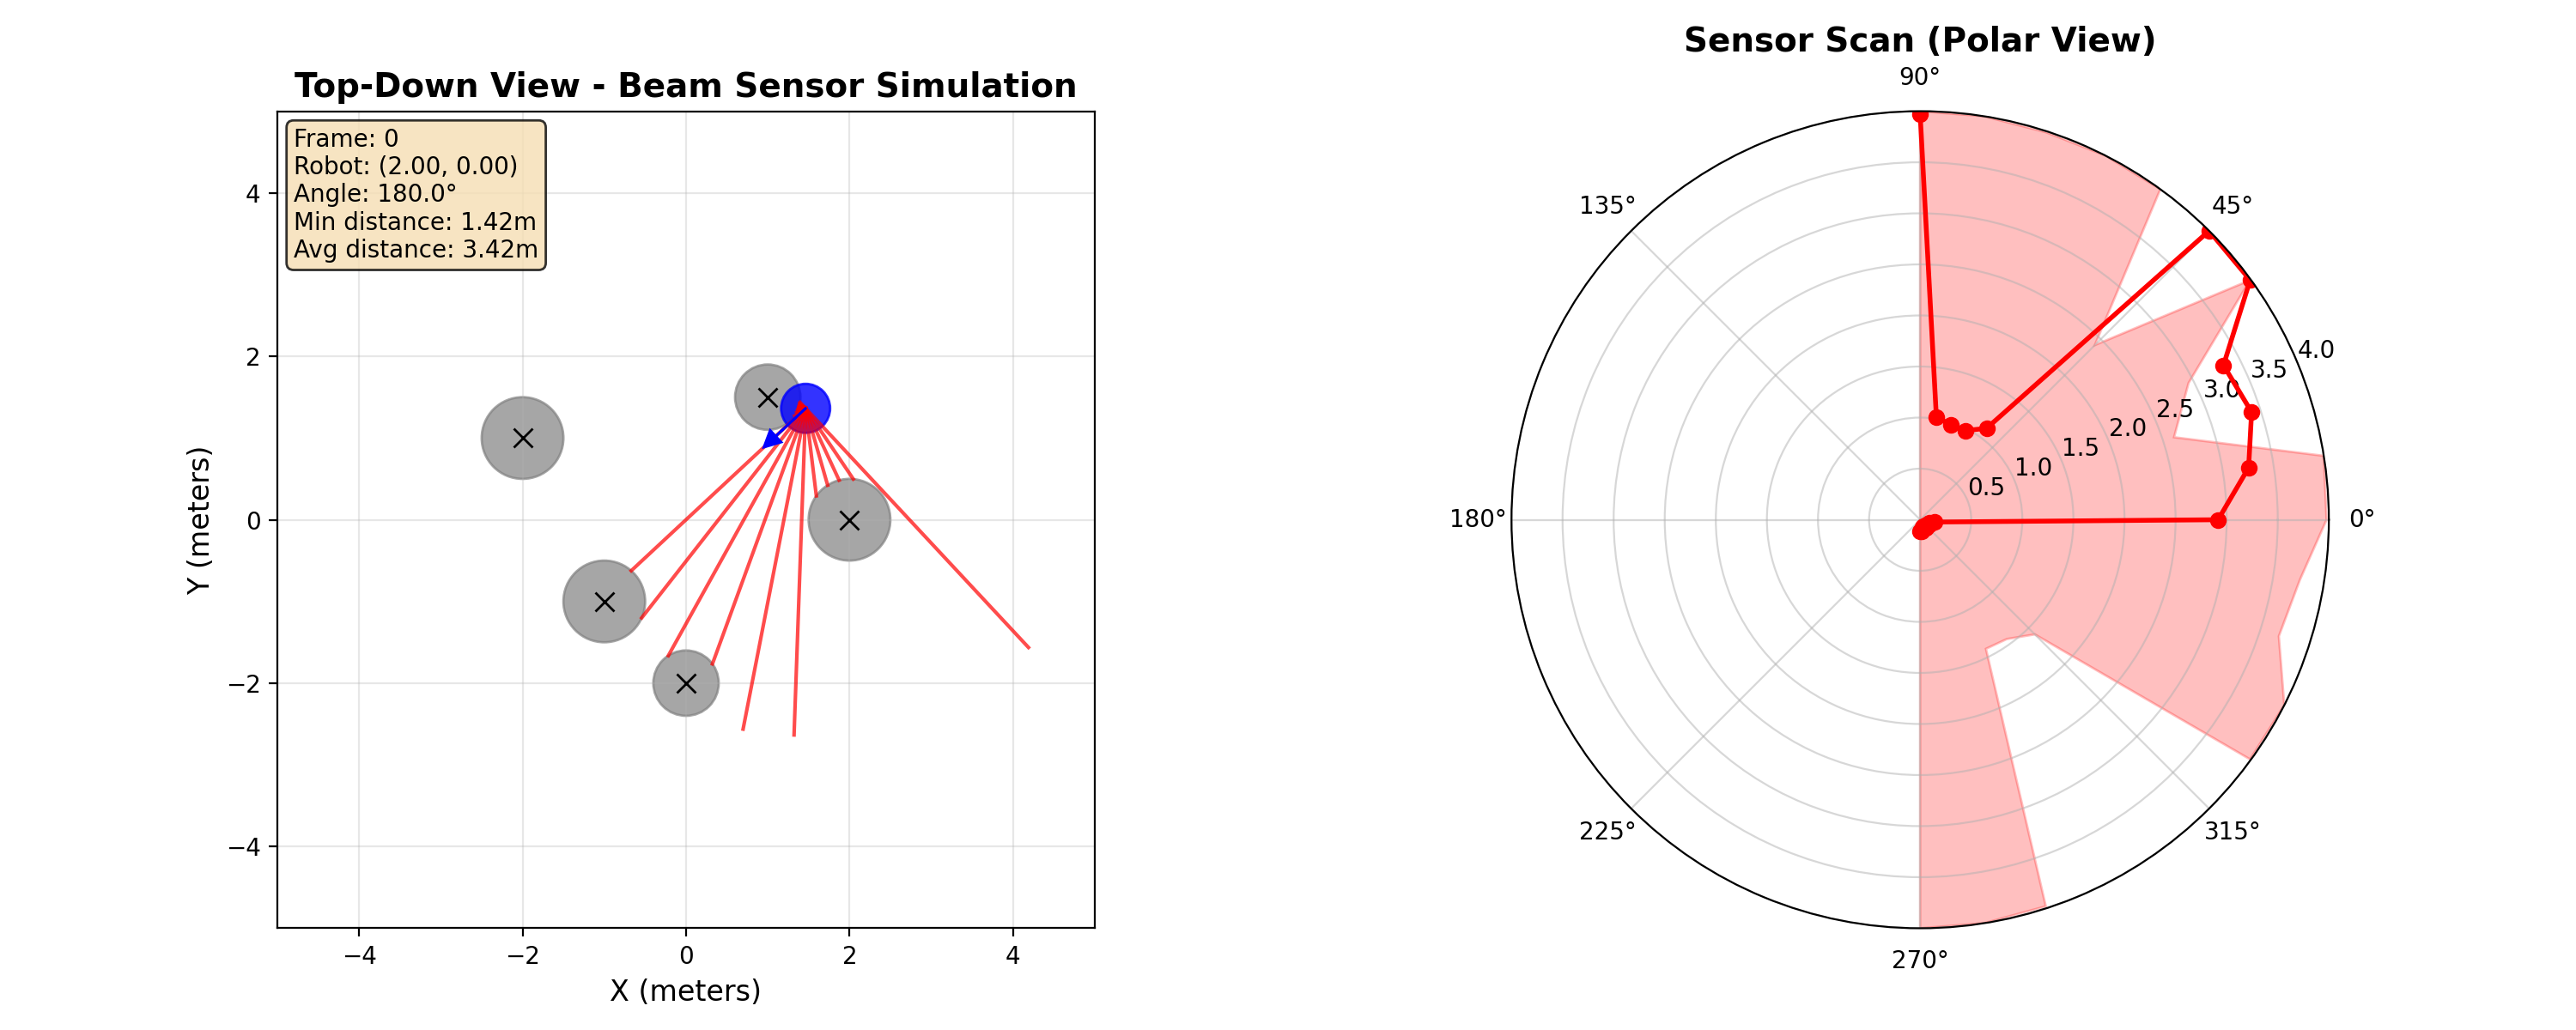

In [3]:
anim, fig = run_simulation()
